# Compare Final Supercooling between different Model Runs

The degree of supercooling is given by

$$ \Delta T_{SC} = T_F - T $$


We distinguish between 
- **model potential supercooling**: with $T_F$ as the (constant) model freezing point -1.9
- **physical potential supercooling**: with $T=T_{pot}$ and $T_F = T_F(p=0,S)$ (physical surface-referenced freezing point)
- **in-situ supercooling**: with $T=T_{in-situ}$ and $T_F = T_F(p,S)$ (physical in-situ freezing point)

In [1]:
# packages for data processing
import numpy as np
import pandas as pd
import xarray as xr
from xmitgcm import open_mdsdataset
import gsw as gsw

# packages for plotting
import matplotlib.pyplot as plt
import plotly.graph_objects as go # interactive/3D plotting
import plotly.express as px
import cmocean.cm as cmo # ocean colormaps

# my own plotting functions
from plotting_functions import *

# technical packages
import warnings

## Load Data

In [26]:
# we load the depth statistics creaetd in supercooling.ipynb
model_runs = [f"MIZ{i:03d}" for i in range(9,21)] # model runs to loop through

insituSC_frac = pd.DataFrame()
insituSC_mean_positive = pd.DataFrame()
potSC_frac = pd.DataFrame()
potSC_mean_positive = pd.DataFrame()

for i in range(len(model_runs)):
    run = model_runs[i]
    filename = run + "_SC_depth_stats_final.nc"
    
    SC_depth_stats = xr.open_dataset(filename)    

    if i == 0:
        # set depth as index
        index = pd.Index(SC_depth_stats.Z, name = "depth")
        insituSC_frac.index = index
        insituSC_mean_positive.index = index
        potSC_frac.index = index
        potSC_mean_positive.index = index

    insituSC_frac[run] = SC_depth_stats.insituSC_frac
    insituSC_mean_positive[run] = SC_depth_stats.insituSC_mean_positive
    potSC_frac[run] = SC_depth_stats.potSC_frac
    potSC_mean_positive[run] = SC_depth_stats.potSC_mean_positive        

insituSC_mean_positive.head()

sh: getfattr: command not found
sh: getfattr: command not found
sh: getfattr: command not found
sh: getfattr: command not found
sh: getfattr: command not found
sh: getfattr: command not found
sh: getfattr: command not found
sh: getfattr: command not found
sh: getfattr: command not found
sh: getfattr: command not found
sh: getfattr: command not found
sh: getfattr: command not found


,MIZ009,MIZ010,MIZ011,MIZ012,MIZ013,MIZ014,MIZ015,MIZ016,MIZ017,MIZ018,MIZ019,MIZ020
depth,,,,,,,,,,,,
-0.50,0.081179,0.047266,0.093006,0.074578,0.081634,0.021237,0.094640,0.090917,0.076363,0.084178,0.079958,0.040960
-1.55,0.064229,0.032423,0.079352,0.058987,0.064180,0.010242,0.078297,0.075590,0.060221,0.062959,0.076708,0.082427
-2.70,0.054891,0.022085,0.071620,0.052435,0.052829,0.007155,0.068172,0.066557,0.054300,0.050611,0.066827,0.074943
-3.90,0.046142,0.016451,0.061496,0.043816,0.042529,0.002245,0.058158,0.056381,0.047130,0.039491,0.057081,0.065620
-5.15,0.037081,0.016049,0.051089,0.034695,0.033130,NaN,0.048005,0.046129,0.038410,0.028782,0.047390,0.054969


## Plot

Let's make a plot with in situ on top and potSC on the bottom. In each axes, we put two axis: one for fraction and one for mean.

### Gen 1

In these simulations (model run MIZ009 to MIZ021), the heat & salt forcing go all the way until the nothern boundary. It seems like this creates some artefacts, namely some sort of boundary plume descending at the northern boundary. This boundary plume transport cold water to the mixed layer bottom, which then flows through the whole model domain and cools the domain from below. I think this might be the reason, why we see a peak of potential supercooling in the subsurface.

Text(0.5, 0.98, 'In Situ Supercooling - Depth Statistics\n')

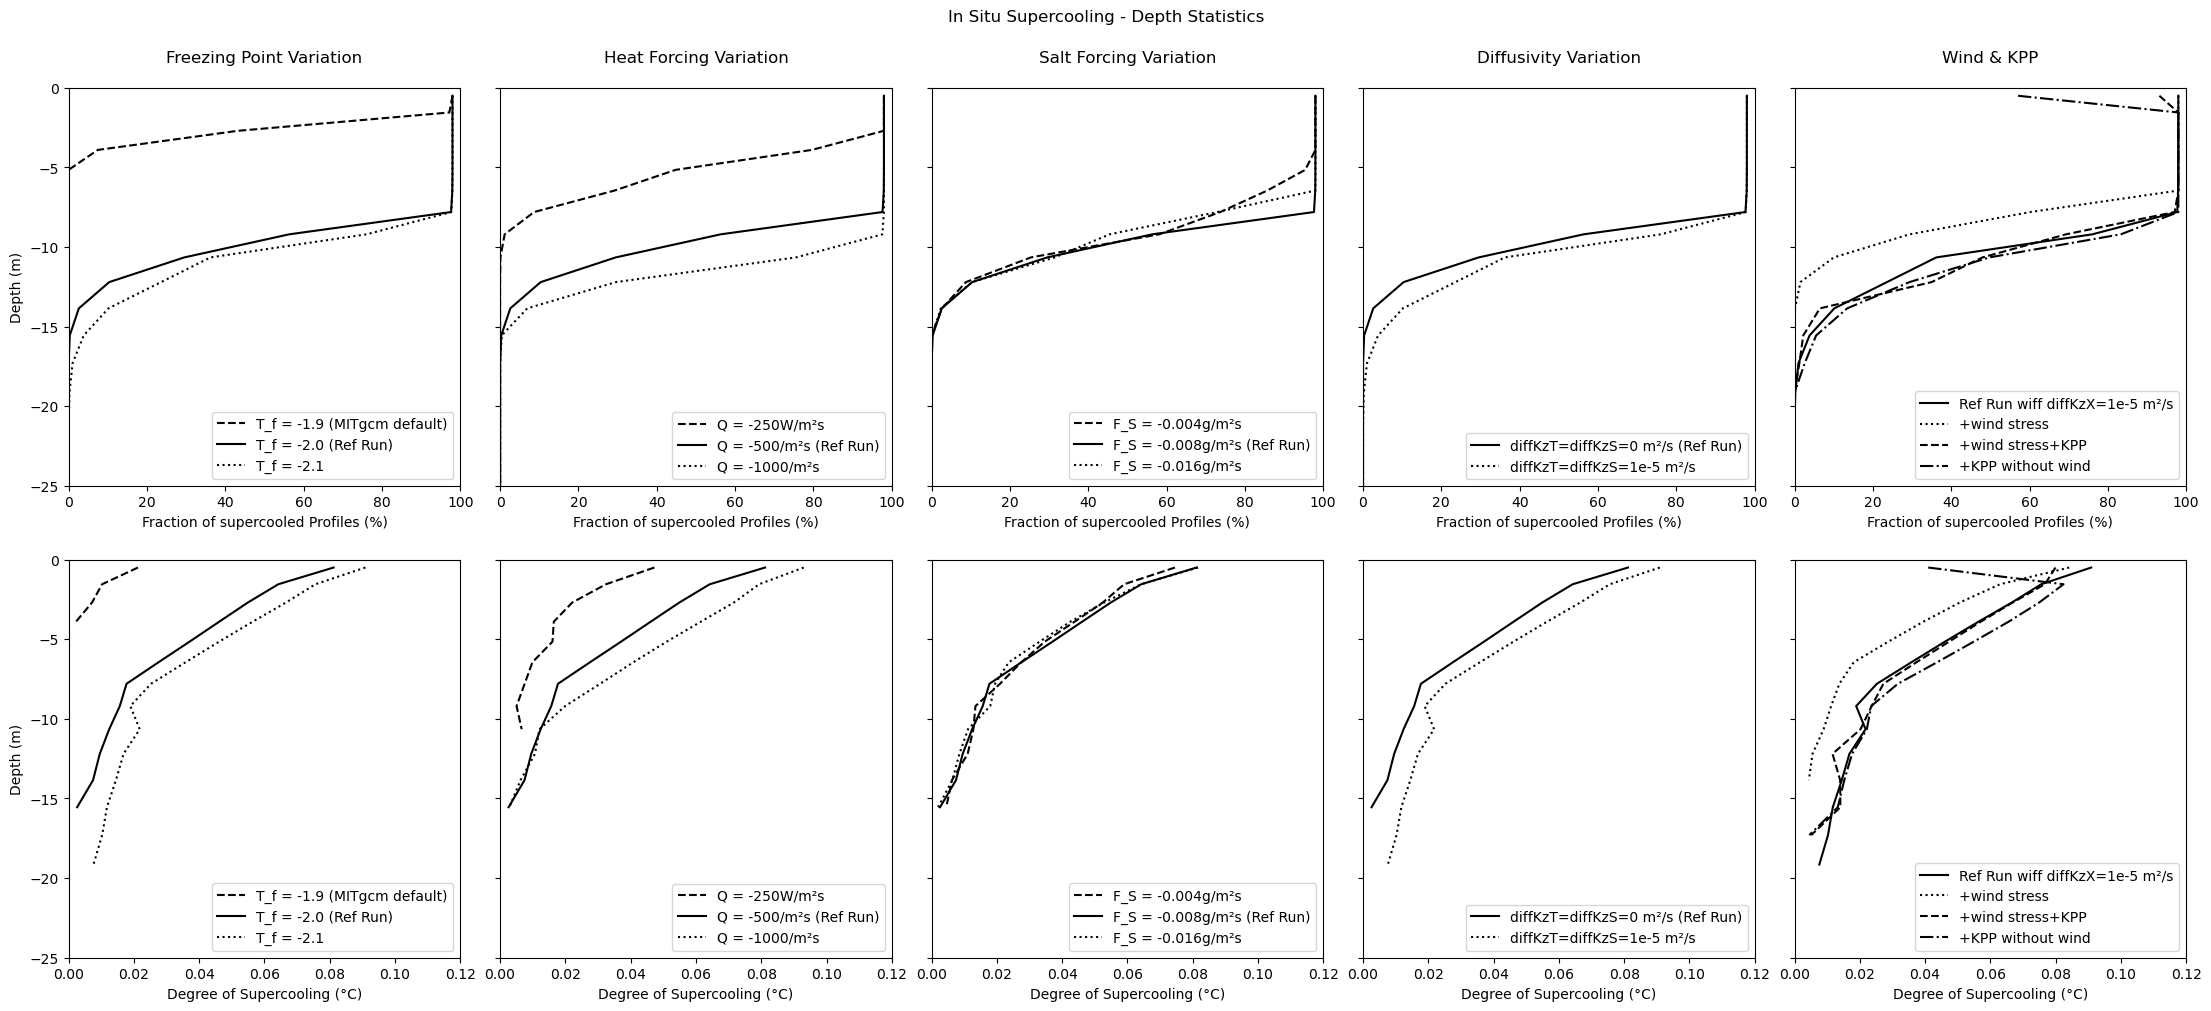

In [27]:
#### IN SITU SUPERCOOLING
fig, axs = plt.subplots(2,5, figsize = (22,10), sharey = True, constrained_layout = True)

col_frac = "black"
col_SC = "black"

# FREEZING POINT VARIATION ----------------------------
axs[0,0].set_title("Freezing Point Variation\n")

# fractions
axs[0,0].plot(insituSC_frac.MIZ014, insituSC_frac.index, label = "T_f = -1.9 (MITgcm default)", color = col_frac, linestyle = "dashed")
axs[0,0].plot(insituSC_frac.MIZ009, insituSC_frac.index, label = "T_f = -2.0 (Ref Run)", color = col_frac)
axs[0,0].plot(insituSC_frac.MIZ016, insituSC_frac.index, label = "T_f = -2.1", color = col_frac, linestyle = "dotted")
axs[0,0].set_xlabel("Fraction of supercooled Profiles (%)", color = col_frac)
axs[0,0].set_ylabel("Depth (m)")
axs[0,0].set_ylim(-25,0)
axs[0,0].tick_params(axis='x', labelcolor=col_frac)
axs[0,0].set_xlim(0,100)

# mean values
axs[1,0].set_title(" ")
axs[1,0].plot(insituSC_mean_positive.MIZ014, insituSC_mean_positive.index, label = "T_f = -1.9 (MITgcm default)", color = col_SC, linestyle = "dashed")
axs[1,0].plot(insituSC_mean_positive.MIZ009, insituSC_mean_positive.index, label = "T_f = -2.0 (Ref Run)", color = col_SC)
axs[1,0].plot(insituSC_mean_positive.MIZ016, insituSC_mean_positive.index, label = "T_f = -2.1", color = col_SC, linestyle = "dotted")
axs[1,0].set_ylabel("Depth (m)")
axs[1,0].set_ylim(-25,0)
axs[1,0].set_xlim(0,0.12)
axs[1,0].set_xlabel("Degree of Supercooling (°C)", color = col_SC)
axs[1,0].tick_params(axis='x', labelcolor=col_SC)

# HEAT FLUX VARIATIONS -----------------------------
axs[0,1].set_title("Heat Forcing Variation\n")
# fractions
axs[0,1].plot(insituSC_frac.MIZ010, insituSC_frac.index, label = "Q = -250W/m²s", color = col_frac, linestyle = "dashed")
axs[0,1].plot(insituSC_frac.MIZ009, insituSC_frac.index, label = "Q = -500/m²s (Ref Run)", color = col_frac)
axs[0,1].plot(insituSC_frac.MIZ011, insituSC_frac.index, label = "Q = -1000/m²s", color = col_frac, linestyle = "dotted")
axs[0,1].set_xlabel("Fraction of supercooled Profiles (%)", color = col_frac)
axs[0,1].tick_params(axis='x', labelcolor=col_frac)
axs[0,1].set_xlim(0,100)

# mean values
axs[1,1].plot(insituSC_mean_positive.MIZ010, insituSC_mean_positive.index, label = "Q = -250W/m²s", color = col_SC, linestyle = "dashed")
axs[1,1].plot(insituSC_mean_positive.MIZ009, insituSC_mean_positive.index, label = "Q = -500/m²s (Ref Run)", color = col_SC)
axs[1,1].plot(insituSC_mean_positive.MIZ011, insituSC_mean_positive.index, label = "Q = -1000/m²s", color = col_SC, linestyle = "dotted")
axs[1,1].set_xlim(0,0.12)
axs[1,1].set_xlabel("Degree of Supercooling (°C)", color = col_SC)
axs[1,1].tick_params(axis='x', labelcolor=col_SC)

# SALT FORCING VARIATION -------------------
axs[0,2].set_title("Salt Forcing Variation\n")
# fractions
axs[0,2].plot(insituSC_frac.MIZ012, insituSC_frac.index, label = "F_S = -0.004g/m²s", color = col_frac, linestyle = "dashed")
axs[0,2].plot(insituSC_frac.MIZ009, insituSC_frac.index, label = "F_S = -0.008g/m²s (Ref Run)", color = col_frac)
axs[0,2].plot(insituSC_frac.MIZ013, insituSC_frac.index, label = "F_S = -0.016g/m²s", color = col_frac, linestyle = "dotted")
axs[0,2].set_xlabel("Fraction of supercooled Profiles (%)", color = col_frac)
axs[0,2].tick_params(axis='x', labelcolor=col_frac)
axs[0,2].set_xlim(0,100)

# mean values
axs[1,2].plot(insituSC_mean_positive.MIZ012, insituSC_mean_positive.index, label = "F_S = -0.004g/m²s", color = col_SC, linestyle = "dashed")
axs[1,2].plot(insituSC_mean_positive.MIZ009, insituSC_mean_positive.index, label = "F_S = -0.008g/m²s (Ref Run)", color = col_SC)
axs[1,2].plot(insituSC_mean_positive.MIZ013, insituSC_mean_positive.index, label = "F_S = -0.016g/m²s", color = col_SC, linestyle = "dotted")
axs[1,2].set_xlim(0,0.12)
axs[1,2].set_xlabel("Degree of Supercooling (°C)", color = col_SC)
axs[1,2].tick_params(axis='x', labelcolor=col_SC)

# Diffusivity VARIATION -------------------
axs[0,3].set_title("Diffusivity Variation\n")
# fractions
axs[0,3].plot(insituSC_frac.MIZ009, insituSC_frac.index, label = "diffKzT=diffKzS=0 m²/s (Ref Run)", color = col_frac)
axs[0,3].plot(insituSC_frac.MIZ016, insituSC_frac.index, label = "diffKzT=diffKzS=1e-5 m²/s", color = col_frac, linestyle = "dotted")

axs[0,3].set_xlabel("Fraction of supercooled Profiles (%)", color = col_frac)
axs[0,3].tick_params(axis='x', labelcolor=col_frac)
axs[0,3].set_xlim(0,100)

# mean values
axs[1,3].plot(insituSC_mean_positive.MIZ009, insituSC_mean_positive.index, label = "diffKzT=diffKzS=0 m²/s (Ref Run)", color = col_SC)
axs[1,3].plot(insituSC_mean_positive.MIZ016, insituSC_mean_positive.index, label = "diffKzT=diffKzS=1e-5 m²/s", color = col_SC, linestyle = "dotted")

axs[1,3].set_xlim(0,0.12)
axs[1,3].set_xlabel("Degree of Supercooling (°C)", color = col_SC)
axs[1,3].tick_params(axis='x', labelcolor=col_SC)

# Wind & KPP  -------------------
axs[0,4].set_title("Wind & KPP\n")
# fractions
axs[0,4].plot(insituSC_frac.MIZ016, insituSC_frac.index, label = "Ref Run wiff diffKzX=1e-5 m²/s", color = col_frac)
axs[0,4].plot(insituSC_frac.MIZ018, insituSC_frac.index, label = "+wind stress", color = col_frac, linestyle = "dotted")
axs[0,4].plot(insituSC_frac.MIZ019, insituSC_frac.index, label = "+wind stress+KPP", color = col_frac, linestyle = "dashed")
axs[0,4].plot(insituSC_frac.MIZ020, insituSC_frac.index, label = "+KPP without wind", color = col_frac, linestyle = "dashdot")

axs[0,4].set_xlabel("Fraction of supercooled Profiles (%)", color = col_frac)
axs[0,4].tick_params(axis='x', labelcolor=col_frac)
axs[0,4].set_xlim(0,100)

# mean values
axs[1,4].plot(insituSC_mean_positive.MIZ016, insituSC_mean_positive.index, label = "Ref Run wiff diffKzX=1e-5 m²/s", color = col_frac)
axs[1,4].plot(insituSC_mean_positive.MIZ018, insituSC_mean_positive.index, label = "+wind stress", color = col_frac, linestyle = "dotted")
axs[1,4].plot(insituSC_mean_positive.MIZ019, insituSC_mean_positive.index, label = "+wind stress+KPP", color = col_frac, linestyle = "dashed")
axs[1,4].plot(insituSC_mean_positive.MIZ020, insituSC_mean_positive.index, label = "+KPP without wind", color = col_frac, linestyle = "dashdot")

axs[1,4].set_xlim(0,0.12)
axs[1,4].set_xlabel("Degree of Supercooling (°C)", color = col_SC)
axs[1,4].tick_params(axis='x', labelcolor=col_SC)



for ax in axs.flatten():
    ax.legend(loc = "lower right")

fig.suptitle("In Situ Supercooling - Depth Statistics\n")

Text(0.5, 0.98, 'Potential Supercooling - Depth Statistics\n')

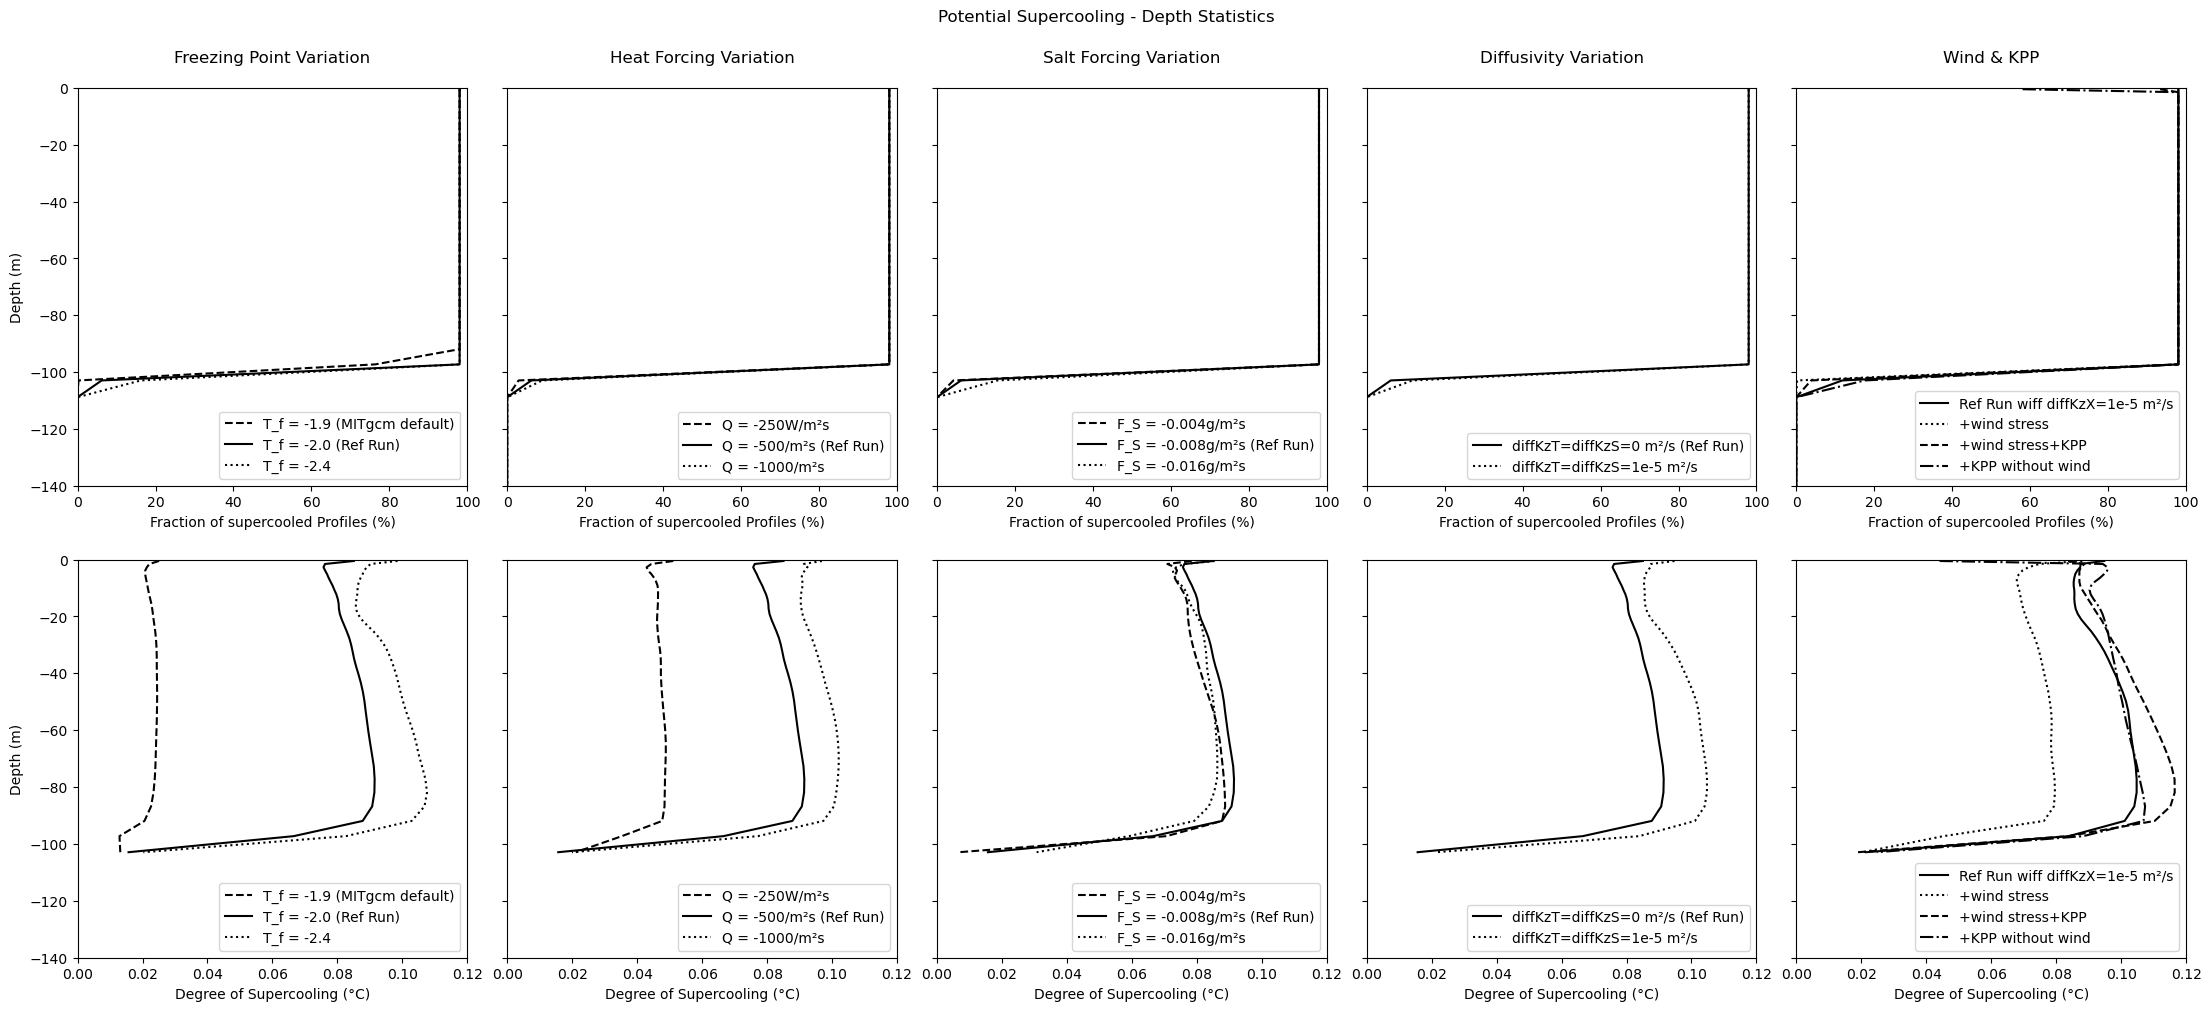

In [28]:
#### Potential SUPERCOOLING
fig, axs = plt.subplots(2,5, figsize = (22,10), sharey = True, constrained_layout = True)

col_frac = "black"
col_SC = "black"

# FREEZING POINT VARIATION ----------------------------
axs[0,0].set_title("Freezing Point Variation\n")

# fractions
axs[0,0].plot(potSC_frac.MIZ014, potSC_frac.index, label = "T_f = -1.9 (MITgcm default)", color = col_frac, linestyle = "dashed")
axs[0,0].plot(potSC_frac.MIZ009, potSC_frac.index, label = "T_f = -2.0 (Ref Run)", color = col_frac)
axs[0,0].plot(potSC_frac.MIZ015, potSC_frac.index, label = "T_f = -2.4", color = col_frac, linestyle = "dotted")
axs[0,0].set_xlabel("Fraction of supercooled Profiles (%)", color = col_frac)
axs[0,0].set_ylabel("Depth (m)")
axs[0,0].set_ylim(-140,0)
axs[0,0].tick_params(axis='x', labelcolor=col_frac)
axs[0,0].set_xlim(0,100)

# mean values
axs[1,0].set_title(" ")
axs[1,0].plot(potSC_mean_positive.MIZ014, potSC_mean_positive.index, label = "T_f = -1.9 (MITgcm default)", color = col_SC, linestyle = "dashed")
axs[1,0].plot(potSC_mean_positive.MIZ009, potSC_mean_positive.index, label = "T_f = -2.0 (Ref Run)", color = col_SC)
axs[1,0].plot(potSC_mean_positive.MIZ015, potSC_mean_positive.index, label = "T_f = -2.4", color = col_SC, linestyle = "dotted")
axs[1,0].set_ylabel("Depth (m)")
axs[1,0].set_xlim(0,0.12)
axs[1,0].set_xlabel("Degree of Supercooling (°C)", color = col_SC)
axs[1,0].tick_params(axis='x', labelcolor=col_SC)

# HEAT FLUX VARIATIONS -----------------------------
axs[0,1].set_title("Heat Forcing Variation\n")
# fractions
axs[0,1].plot(potSC_frac.MIZ010, potSC_frac.index, label = "Q = -250W/m²s", color = col_frac, linestyle = "dashed")
axs[0,1].plot(potSC_frac.MIZ009, potSC_frac.index, label = "Q = -500/m²s (Ref Run)", color = col_frac)
axs[0,1].plot(potSC_frac.MIZ011, potSC_frac.index, label = "Q = -1000/m²s", color = col_frac, linestyle = "dotted")
axs[0,1].set_xlabel("Fraction of supercooled Profiles (%)", color = col_frac)
axs[0,1].tick_params(axis='x', labelcolor=col_frac)
axs[0,1].set_xlim(0,100)

# mean values
axs[1,1].plot(potSC_mean_positive.MIZ010, potSC_mean_positive.index, label = "Q = -250W/m²s", color = col_SC, linestyle = "dashed")
axs[1,1].plot(potSC_mean_positive.MIZ009, potSC_mean_positive.index, label = "Q = -500/m²s (Ref Run)", color = col_SC)
axs[1,1].plot(potSC_mean_positive.MIZ011, potSC_mean_positive.index, label = "Q = -1000/m²s", color = col_SC, linestyle = "dotted")
axs[1,1].set_xlim(0,0.12)
axs[1,1].set_xlabel("Degree of Supercooling (°C)", color = col_SC)
axs[1,1].tick_params(axis='x', labelcolor=col_SC)

# SALT FORCING VARIATION -------------------
axs[0,2].set_title("Salt Forcing Variation\n")
# fractions
axs[0,2].plot(potSC_frac.MIZ012, potSC_frac.index, label = "F_S = -0.004g/m²s", color = col_frac, linestyle = "dashed")
axs[0,2].plot(potSC_frac.MIZ009, potSC_frac.index, label = "F_S = -0.008g/m²s (Ref Run)", color = col_frac)
axs[0,2].plot(potSC_frac.MIZ013, potSC_frac.index, label = "F_S = -0.016g/m²s", color = col_frac, linestyle = "dotted")
axs[0,2].set_xlabel("Fraction of supercooled Profiles (%)", color = col_frac)
axs[0,2].tick_params(axis='x', labelcolor=col_frac)
axs[0,2].set_xlim(0,100)

# mean values
axs[1,2].plot(potSC_mean_positive.MIZ012, potSC_mean_positive.index, label = "F_S = -0.004g/m²s", color = col_SC, linestyle = "dashed")
axs[1,2].plot(potSC_mean_positive.MIZ009, potSC_mean_positive.index, label = "F_S = -0.008g/m²s (Ref Run)", color = col_SC)
axs[1,2].plot(potSC_mean_positive.MIZ013, potSC_mean_positive.index, label = "F_S = -0.016g/m²s", color = col_SC, linestyle = "dotted")
axs[1,2].set_xlim(0,0.12)
axs[1,2].set_xlabel("Degree of Supercooling (°C)", color = col_SC)
axs[1,2].tick_params(axis='x', labelcolor=col_SC)


# Diffusivity VARIATION -------------------
axs[0,3].set_title("Diffusivity Variation\n")
# fractions
axs[0,3].plot(potSC_frac.MIZ009, potSC_frac.index, label = "diffKzT=diffKzS=0 m²/s (Ref Run)", color = col_frac)
axs[0,3].plot(potSC_frac.MIZ016, potSC_frac.index, label = "diffKzT=diffKzS=1e-5 m²/s", color = col_frac, linestyle = "dotted")

axs[0,3].set_xlabel("Fraction of supercooled Profiles (%)", color = col_frac)
axs[0,3].tick_params(axis='x', labelcolor=col_frac)
axs[0,3].set_xlim(0,100)

# mean values
axs[1,3].plot(potSC_mean_positive.MIZ009, potSC_mean_positive.index, label = "diffKzT=diffKzS=0 m²/s (Ref Run)", color = col_SC)
axs[1,3].plot(potSC_mean_positive.MIZ016, potSC_mean_positive.index, label = "diffKzT=diffKzS=1e-5 m²/s", color = col_SC, linestyle = "dotted")

axs[1,3].set_xlim(0,0.12)
axs[1,3].set_xlabel("Degree of Supercooling (°C)", color = col_SC)
axs[1,3].tick_params(axis='x', labelcolor=col_SC)

# Wind & KPP  -------------------
axs[0,4].set_title("Wind & KPP\n")
# fractions
axs[0,4].plot(potSC_frac.MIZ016, potSC_frac.index, label = "Ref Run wiff diffKzX=1e-5 m²/s", color = col_frac)
axs[0,4].plot(potSC_frac.MIZ018, potSC_frac.index, label = "+wind stress", color = col_frac, linestyle = "dotted")
axs[0,4].plot(potSC_frac.MIZ019, potSC_frac.index, label = "+wind stress+KPP", color = col_frac, linestyle = "dashed")
axs[0,4].plot(potSC_frac.MIZ020, potSC_frac.index, label = "+KPP without wind", color = col_frac, linestyle = "dashdot")

axs[0,4].set_xlabel("Fraction of supercooled Profiles (%)", color = col_frac)
axs[0,4].tick_params(axis='x', labelcolor=col_frac)
axs[0,4].set_xlim(0,100)

# mean values
axs[1,4].plot(potSC_mean_positive.MIZ016, potSC_mean_positive.index, label = "Ref Run wiff diffKzX=1e-5 m²/s", color = col_frac)
axs[1,4].plot(potSC_mean_positive.MIZ018, potSC_mean_positive.index, label = "+wind stress", color = col_frac, linestyle = "dotted")
axs[1,4].plot(potSC_mean_positive.MIZ019, potSC_mean_positive.index, label = "+wind stress+KPP", color = col_frac, linestyle = "dashed")
axs[1,4].plot(potSC_mean_positive.MIZ020, potSC_mean_positive.index, label = "+KPP without wind", color = col_frac, linestyle = "dashdot")

axs[1,4].set_xlim(0,0.12)
axs[1,4].set_xlabel("Degree of Supercooling (°C)", color = col_SC)
axs[1,4].tick_params(axis='x', labelcolor=col_SC)

for ax in axs.flatten():
    ax.legend(loc = "lower right")

fig.suptitle("Potential Supercooling - Depth Statistics\n")

### Gen 2